<img src="../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../images/Konstanz_Logo.svg" width="200" /> <img src="../images/KIT_Logo.png" width="200" />

# Sentiment Analysis with NLTK and Naive Bayes

We build a classifier that reads an Amazon product review and predicts whether
the customer was **satisfied** or not.

The path we take: look at the data first, then zoom all the way in on a *single*
review to understand each preprocessing step, then zoom back out and apply those
steps to all reviews.

---

## Contents

1. [Setup](#setup)
2. [The data](#data)
3. [Anatomy of a single review](#anatomy)
4. [From one review to all reviews](#pipeline)
5. [Turning words into numbers](#features)
6. [Splitting the data](#split)
7. [Training the model](#model)
8. [Evaluation](#evaluation)

<a id="setup"></a>
## 1. Setup

`nltk` ships without its data files, so we download the ones we need: a tokenizer
(`punkt`), a part-of-speech tagger, and the WordNet dictionary used for
lemmatization. Newer NLTK versions renamed some of these, so we simply request
both spellings.

In [17]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt

for resource in ["punkt", "punkt_tab",
                 "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
                 "wordnet", "omw-1.4", "tagsets", "tagsets_json"]:
    nltk.download(resource, quiet=True)

print("nltk", nltk.__version__)

nltk 3.9.1


<a id="data"></a>
## 2. The data

*Data source: [https://www.kaggle.com/datasets/kritanjalijain/amazon-reviews/](https://www.kaggle.com/datasets/kritanjalijain/amazon-reviews/)*

A balanced sample of Amazon product reviews. Each row holds the review text and
a boolean label: `True` if the customer was satisfied, `False` if not.

In [3]:
df = pd.read_csv("Amazon_Reviews.csv")
df.head()

,Review_Text,Satisfied
0,"I absolutely loved Phantom, as I have most of ...",True
1,I purchased this radio NEW not reconditioned t...,False
2,This tasted ok... had to add sweetener. Howeve...,True
3,This movie is really hard to watch because the...,False
4,"Let's get it straight, this is not a movie to ...",True


In [5]:
print("Rows:    ", len(df))
print("Missing: ", df.isna().sum().sum())

Rows:     6419
Missing:  0


### 2.1 How are the labels distributed?

Before training anything, check the balance of the target variable. This tells us
what a *trivial* model would score — one that ignores the text entirely and always
guesses the more common class.

In [6]:
label_shares = df["Satisfied"].value_counts(normalize=True)
label_shares

,proportion
Satisfied,
False,0.510204
True,0.489796


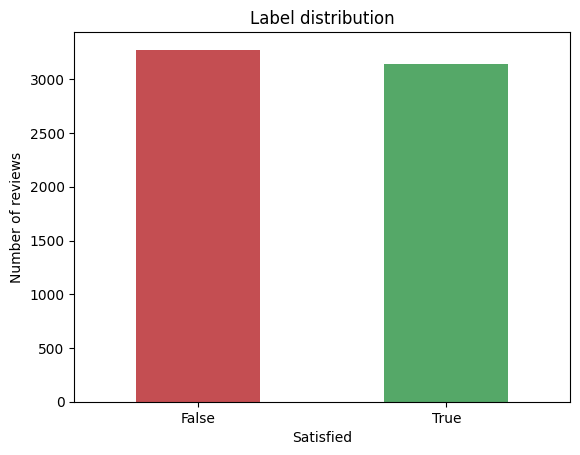

In [7]:
df["Satisfied"].value_counts().plot(kind="bar", rot=0, color=["#c44e52", "#55a868"])
plt.title("Label distribution")
plt.ylabel("Number of reviews")
plt.show()

The classes are nearly balanced, so guessing the majority class every time would
land at roughly 51% accuracy. **That is the number our model has to beat** — an
accuracy of 55% would be a poor result, not a good one.

In [8]:
baseline_accuracy = label_shares.max()
print(f"Baseline (always guess the majority class): {baseline_accuracy:.1%}")

Baseline (always guess the majority class): 51.0%


<a id="anatomy"></a>
## 3. Anatomy of a single review

A model cannot consume raw text — it needs numbers. Getting there takes several
steps, and the clearest way to understand them is to watch them happen to one
concrete example. We take the very first review of the dataset and carry it
through the whole chain.

In [10]:
sample_review = df.loc[0, "Review_Text"]
sample_label = df.loc[0, "Satisfied"]

print(f"Satisfied: {sample_label}\n")
print(sample_review)

Satisfied: True

I absolutely loved Phantom, as I have most of the Sword of Truth series (with the exception of Pillars of Creation and Naked Empire). Phantom deffinetly gets 5 stars, it didn't end as I wanted it to, but I still loved it, I read alot of reviews taht said it was to repetitive but I disagree, it was just a strong point in the book. I saw more low stars then high stars for this book and I wonder why, but I am probably one of the younger readers and I guess its just a different perspective I have, and for anyone considering whether to read this book I highly recommend it, but you must read the other's first, your could probably manage skipping POC and NE though, they WERE pointless.Overall I MUST give Goodkind props, I loved this book and it had me all over with all the twists and new exciting challenges it presented to the characters. So READ IT and I hope you'll enjoy it as much as I did.


### 3.1 Tokenization

Splitting a string into its individual words and punctuation marks. Note that
`word_tokenize` is smarter than `text.split()` — it separates punctuation from
words and handles contractions like "didn't".

In [11]:
tokens = nltk.word_tokenize(sample_review)
tokens[:25]

['I',
 'absolutely',
 'loved',
 'Phantom',
 ',',
 'as',
 'I',
 'have',
 'most',
 'of',
 'the',
 'Sword',
 'of',
 'Truth',
 'series',
 '(',
 'with',
 'the',
 'exception',
 'of',
 'Pillars',
 'of',
 'Creation',
 'and',
 'Naked']

### 3.2 Lowercasing

Without this, "Great" and "great" would count as two unrelated features.

In [12]:
lowercase_tokens = [token.lower() for token in tokens]
lowercase_tokens[:25]

['i',
 'absolutely',
 'loved',
 'phantom',
 ',',
 'as',
 'i',
 'have',
 'most',
 'of',
 'the',
 'sword',
 'of',
 'truth',
 'series',
 '(',
 'with',
 'the',
 'exception',
 'of',
 'pillars',
 'of',
 'creation',
 'and',
 'naked']

### 3.3 Part-of-speech tagging

Each token gets a label describing its grammatical role — noun, verb, adjective,
and so on. We need this because we are about to keep **only the adjectives**:
sentiment in a product review sits mostly in words like *great*, *broken*,
*disappointing*.

In [15]:
pos_tags = nltk.pos_tag(lowercase_tokens)

pd.DataFrame(pos_tags, columns=["Token", "POS-Tag"]).head(20)

,Token,POS-Tag
0,i,NN
1,absolutely,RB
2,loved,VBD
3,phantom,NN
4,",",","
5,as,IN
6,i,NNS
7,have,VBP
8,most,JJS
9,of,IN


The tags come from the Penn Treebank tag set. The three that matter for us all
start with `J`:

In [18]:
nltk.help.upenn_tagset("JJ.*")

JJ: adjective or numeral, ordinal
    third ill-mannered pre-war regrettable oiled calamitous first separable
    ectoplasmic battery-powered participatory fourth still-to-be-named
    multilingual multi-disciplinary ...
JJR: adjective, comparative
    bleaker braver breezier briefer brighter brisker broader bumper busier
    calmer cheaper choosier cleaner clearer closer colder commoner costlier
    cozier creamier crunchier cuter ...
JJS: adjective, superlative
    calmest cheapest choicest classiest cleanest clearest closest commonest
    corniest costliest crassest creepiest crudest cutest darkest deadliest
    dearest deepest densest dinkiest ...


> Calling `nltk.help.upenn_tagset()` without an argument prints the complete list
> of all ~36 tags.

### 3.4 Filtering and lemmatizing

Now we keep the adjectives and reduce each one to its dictionary form. This is
**lemmatization**: `happier` and `happiest` both become `happy`, so the model
sees one feature instead of three.

In [20]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn

lemmatizer = WordNetLemmatizer()

# What lemmatization does, in isolation:
for word in ["happier", "happiest", "greatest", "cheaper", "worst"]:
    print(f"{word:>10}  ->  {lemmatizer.lemmatize(word, pos=wn.ADJ)}")

   happier  ->  happy
  happiest  ->  happy
  greatest  ->  great
   cheaper  ->  cheap
     worst  ->  bad


<a id="pipeline"></a>
## 4. From one review to all reviews

The four steps above always run together, so we wrap them in a single function
and verify it reproduces our manual result.

In [23]:
def extract_adjectives(text):
    tokens = nltk.word_tokenize(text)
    lowercase_tokens = [token.lower() for token in tokens]
    pos_tags = nltk.pos_tag(lowercase_tokens)
    adjectives = [
        lemmatizer.lemmatize(token, pos=wn.ADJ)
        for token, tag in pos_tags
        if tag.startswith("J")
    ]
    return " ".join(adjectives)

In [24]:
extract_adjectives(sample_review)

'most naked i strong low high i young i different other first ne pointless.overall new read much'

Now apply it to every row.

In [26]:
df["Adjectives"] = df["Review_Text"].apply(extract_adjectives)

df[["Review_Text", "Adjectives", "Satisfied"]].head()

,Review_Text,Adjectives,Satisfied
0,"I absolutely loved Phantom, as I have most of ...",most naked i strong low high i young i differe...,True
1,I purchased this radio NEW not reconditioned t...,new outdoor few good industrial tough,False
2,This tasted ok... had to add sweetener. Howeve...,compatible high few,True
3,This movie is really hard to watch because the...,hard black white crystal clear best,False
4,"Let's get it straight, this is not a movie to ...",good,True


<a id="features"></a>
## 5. Turning words into numbers

`CountVectorizer` builds a vocabulary from the texts it is shown, then represents
each text as a row of word counts — one column per vocabulary word. This
representation is called a **bag of words**: word order is discarded, only
frequencies remain.

Four miniature examples make the shape of the output obvious — roughly what
`extract_adjectives` would return for four different customers:

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

demo_docs = [
    "good great good",          # 3 adjectives
    "bad cheap",                # 2 adjectives
    "great",                    # 1 adjective
    "bad slow expensive bad",   # 4 adjectives
]

demo_vectorizer = CountVectorizer()
demo_features = demo_vectorizer.fit_transform(demo_docs)

pd.DataFrame(demo_features.toarray(),
             columns=demo_vectorizer.get_feature_names_out(),
             index=["Review 1 (satisfied)", "Review 2 (unsatisfied)",
                    "Review 3 (satisfied)", "Review 4 (unsatisfied)"])

,bad,cheap,expensive,good,great,slow
Review 1 (satisfied),0,0,0,2,1,0
Review 2 (unsatisfied),1,1,0,0,0,0
Review 3 (satisfied),0,0,0,0,1,0
Review 4 (unsatisfied),2,0,1,0,0,1


Two things to notice:

- Six distinct words appear across the four reviews, so the table has **six
  columns** — and every review gets a value in all of them, most of them zero.
- The reviews had 3, 2, 1 and 4 adjectives, yet all four rows come out the **same
  width**. This is what makes the data usable: texts of any length turn into
  vectors of one fixed size.

On the real dataset the vocabulary would run to several thousand columns, so we
will cap it at the most frequent ones.

<a id="split"></a>
## 6. Splitting the data

We hold back 20% of the reviews to measure performance on data the model has never
seen. `stratify=y` keeps the label proportions identical in both parts.

In [28]:
from sklearn.model_selection import train_test_split

X = df["Adjectives"]
y = df["Satisfied"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

print(f"Training reviews: {len(X_train)}")
print(f"Test reviews:     {len(X_test)}")

Training reviews: 5135
Test reviews:     1284


Now we build the vocabulary. One detail matters a great deal here:

> `fit` is called on the **training data only**. If the vectorizer were allowed to
> see the test set while building its vocabulary, information would leak from the
> test set into the model and our final score would be optimistic.

`max_features=300` keeps the 300 most frequent adjectives and discards the rest —
a knob worth experimenting with.

In [29]:
count_vectorizer = CountVectorizer(max_features=300)
count_vectorizer.fit(X_train)

X_train_vectorized = count_vectorizer.transform(X_train)
X_test_vectorized = count_vectorizer.transform(X_test)

print("Training matrix:", X_train_vectorized.shape)
print("Test matrix:    ", X_test_vectorized.shape)

Training matrix: (5135, 300)
Test matrix:     (1284, 300)


In [30]:
feature_names = count_vectorizer.get_feature_names_out()

pd.DataFrame(X_train_vectorized.toarray(), columns=feature_names).head()

,able,absolute,accurate,actual,afraid,african,alive,all,amazing,amazon,...,whole,wide,wild,willing,wish,wonderful,worth,wrong,year,young
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<a id="model"></a>
## 7. Training the model

**Multinomial Naive Bayes** is the classic choice for bag-of-words data. It learns,
for each word, how much more often it appears in satisfied than in dissatisfied
reviews, and multiplies that evidence together across all words in a review.

It is called *naive* because it assumes the words are independent of one another,
which is plainly false for language — yet it works well in practice, trains in a
fraction of a second, and stays easy to interpret.

In [31]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

MultinomialNB()

<a id="evaluation"></a>
## 8. Evaluation

Time to measure. The number that counts is accuracy on the held-out test set,
compared against the baseline from [section 2.1](#data).

In [32]:
from sklearn.metrics import accuracy_score

y_predict = model.predict(X_test_vectorized)
accuracy = accuracy_score(y_test, y_predict)

print(f"Accuracy: {accuracy:.1%}")
print(f"Baseline: {baseline_accuracy:.1%}")
print(f"Gain:     {accuracy - baseline_accuracy:+.1%}")

Accuracy: 72.3%
Baseline: 51.0%
Gain:     +21.3%


A single accuracy figure still hides *how* the model is wrong. The confusion matrix
breaks the same predictions down by class: the diagonal holds the correct ones,
everything off it is a mistake — the top right are satisfied customers we missed,
the bottom left are complaints we read as praise.

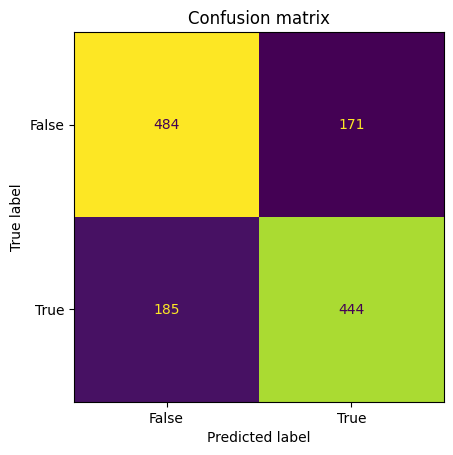

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_predict, colorbar=False)
plt.title("Confusion matrix")
plt.show()